In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

Task 1. Dataset preparation

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [5]:
#MNIST
full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 468kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [6]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [7]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
# Dataset info
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")   # torch.Size([1, 28, 28])
print(f"Data type: {train_dataset[0][0].dtype}")

Training set size: 48000
Validation set size: 12000
Test set size: 10000
Image shape: torch.Size([1, 28, 28])
Data type: torch.float32


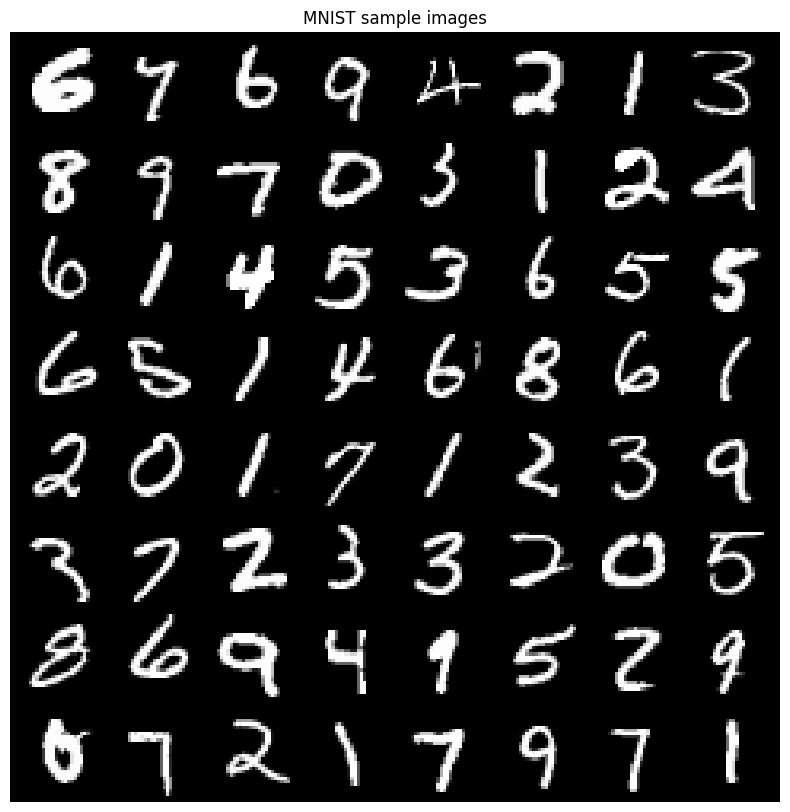

In [9]:
def show_grid(images, title="Original images", nrow=8):
    images = images[:nrow*nrow]
    grid = torchvision.utils.make_grid(images, nrow=nrow, normalize=True)
    plt.figure(figsize=(10,10))
    plt.imshow(grid.permute(1,2,0).cpu().numpy())
    plt.title(title)
    plt.axis('off')
    plt.show()

sample_images = [train_dataset[i][0] for i in range(64)]
show_grid(sample_images, "MNIST sample images")

Task 2. Autoencoder architecture

In [10]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)  # 28 -> 14
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1) # 14 -> 7
        self.fc = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [11]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1) # 7->14
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1) # 14->28

    def forward(self, z):
        z = self.fc(z)
        z = z.view(z.size(0), 64, 7, 7)
        z = F.relu(self.deconv1(z))
        z = torch.sigmoid(self.deconv2(z))
        return z

In [12]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

In [13]:
latent_dim = 64
model = Autoencoder(latent_dim=latent_dim).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Number of trainable parameters: {count_parameters(model)}")
print(f"Latent space dimension: {latent_dim}")

Autoencoder(
  (encoder): Encoder(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (fc): Linear(in_features=3136, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=64, out_features=3136, bias=True)
    (deconv1): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (deconv2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
)
Number of trainable parameters: 442177
Latent space dimension: 64


Task 3. Reconstruction before training

In [14]:
model.eval()
with torch.no_grad():
    sample_batch, _ = next(iter(test_loader))
    sample_batch = sample_batch.to(device)
    recon_batch, _ = model(sample_batch[:8])

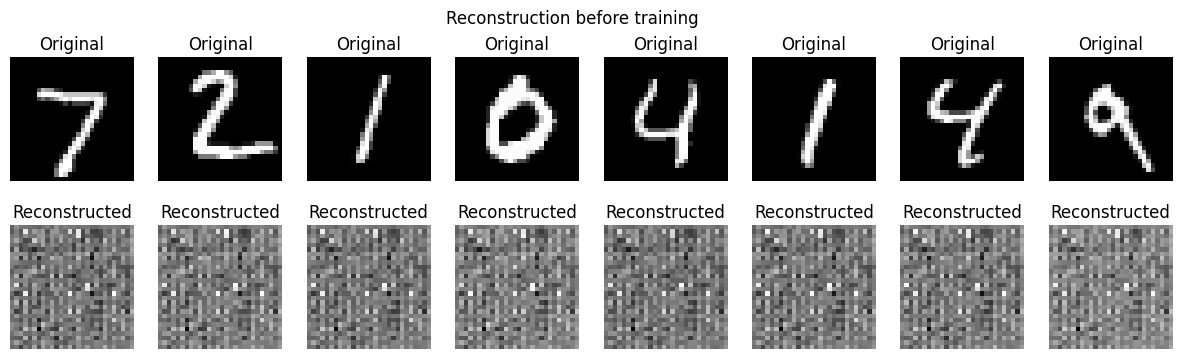

In [15]:
def show_reconstructions(original, reconstructed, title="Reconstruction"):
    fig, axes = plt.subplots(2, len(original), figsize=(15, 4))
    for i in range(len(original)):
        axes[0, i].imshow(original[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title("Original")
        axes[1, i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title("Reconstructed")
    plt.suptitle(title)
    plt.show()

show_reconstructions(sample_batch[:8], recon_batch, "Reconstruction before training")

In [16]:
# Compute MSE before training
mse_loss = nn.MSELoss()
loss_before = mse_loss(recon_batch, sample_batch[:8])
print(f"Average MSE before training: {loss_before.item():.4f}")

Average MSE before training: 0.1988


Task 4. Autoencoder training


In [17]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 20

train_losses = []
val_losses = []

In [18]:
for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        recon, _ = model(images)
        loss = criterion(recon, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * images.size(0)

    epoch_train_loss /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            recon, _ = model(images)
            loss = criterion(recon, images)
            epoch_val_loss += loss.item() * images.size(0)
    epoch_val_loss /= len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

Epoch  1/20 | Train Loss: 0.0264 | Val Loss: 0.0071
Epoch  2/20 | Train Loss: 0.0054 | Val Loss: 0.0044
Epoch  3/20 | Train Loss: 0.0038 | Val Loss: 0.0034
Epoch  4/20 | Train Loss: 0.0032 | Val Loss: 0.0030
Epoch  5/20 | Train Loss: 0.0029 | Val Loss: 0.0028
Epoch  6/20 | Train Loss: 0.0027 | Val Loss: 0.0026
Epoch  7/20 | Train Loss: 0.0025 | Val Loss: 0.0025
Epoch  8/20 | Train Loss: 0.0024 | Val Loss: 0.0024
Epoch  9/20 | Train Loss: 0.0023 | Val Loss: 0.0023
Epoch 10/20 | Train Loss: 0.0022 | Val Loss: 0.0023
Epoch 11/20 | Train Loss: 0.0022 | Val Loss: 0.0022
Epoch 12/20 | Train Loss: 0.0021 | Val Loss: 0.0022
Epoch 13/20 | Train Loss: 0.0021 | Val Loss: 0.0021
Epoch 14/20 | Train Loss: 0.0020 | Val Loss: 0.0021
Epoch 15/20 | Train Loss: 0.0020 | Val Loss: 0.0020
Epoch 16/20 | Train Loss: 0.0020 | Val Loss: 0.0020
Epoch 17/20 | Train Loss: 0.0019 | Val Loss: 0.0020
Epoch 18/20 | Train Loss: 0.0019 | Val Loss: 0.0020
Epoch 19/20 | Train Loss: 0.0019 | Val Loss: 0.0020
Epoch 20/20 

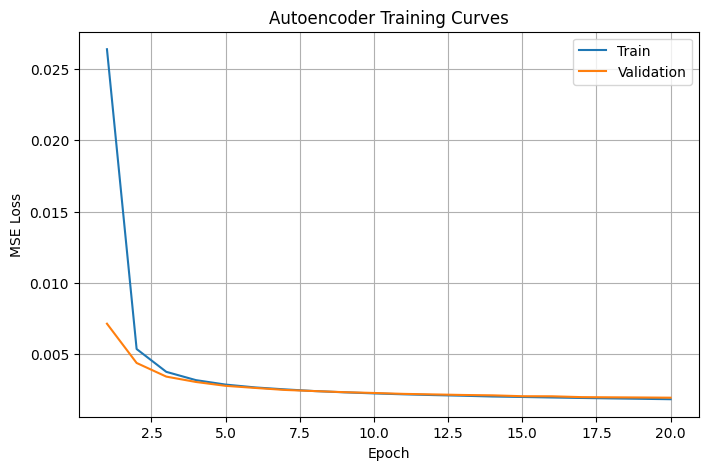

In [19]:
# Plot loss curves
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Curves')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
print(f"Final test reconstruction loss (validation set): {val_losses[-1]:.6f}")

Final test reconstruction loss (validation set): 0.001945


Task 5. Reconstruction quality analysis

In [21]:
model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    recon_test, _ = model(test_images[:8])
    recon_all, _ = model(test_images)

    # MSE per image
    mse_per_image = torch.mean((recon_all - test_images) ** 2, dim=(1,2,3))
    avg_mse = mse_per_image.mean().item()

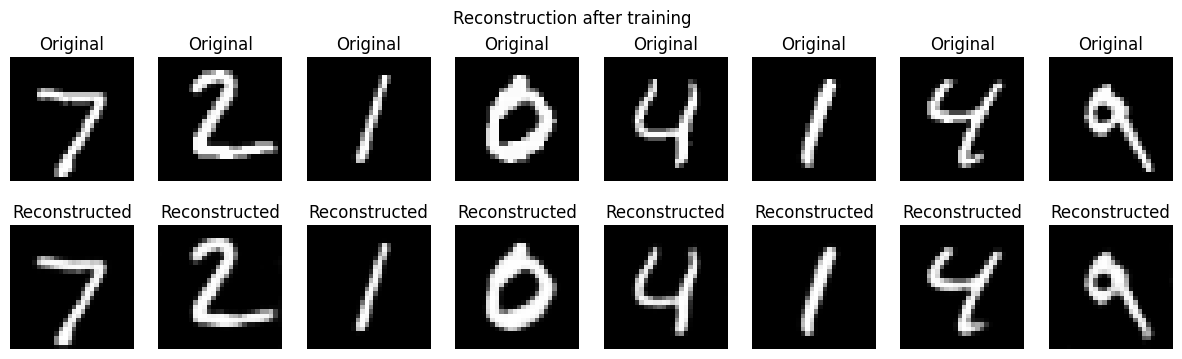

Average MSE on test images after training: 0.001798
Comparison: before training MSE = 0.1988, after training = 0.001798


In [22]:
show_reconstructions(test_images[:8].cpu(), recon_test.cpu(), "Reconstruction after training")
print(f"Average MSE on test images after training: {avg_mse:.6f}")
print(f"Comparison: before training MSE = {loss_before.item():.4f}, after training = {avg_mse:.6f}")

Task 6. Latent space representation

In [23]:
model.eval()
latent_vectors = []
labels_list = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        latent_vectors.append(z.cpu().numpy())
        labels_list.append(labels.numpy())
        if len(latent_vectors) * batch_size >= 1000:
            break

latent_vectors = np.concatenate(latent_vectors, axis=0)[:1000]
labels_list = np.concatenate(labels_list, axis=0)[:1000]

In [24]:
print(f"Shape of a single latent vector: {latent_vectors[0].shape}")

Shape of a single latent vector: (64,)


In [25]:
# PCA to 2D
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_vectors)

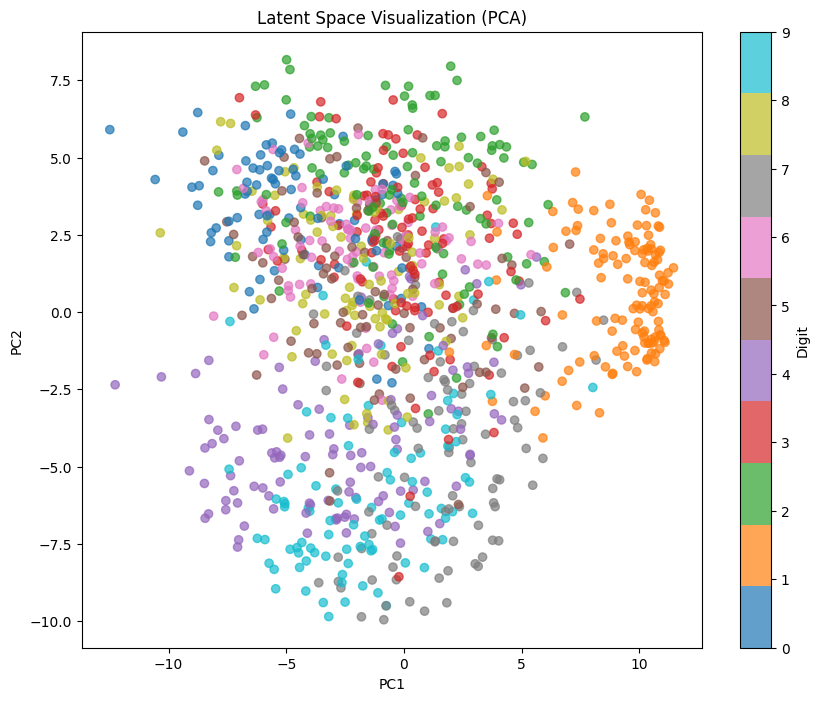

In [26]:
plt.figure(figsize=(10,8))
scatter = plt.scatter(latent_pca[:,0], latent_pca[:,1], c=labels_list, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Digit')
plt.title('Latent Space Visualization (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [27]:
# t-SNE for better separation
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_tsne = tsne.fit_transform(latent_vectors)

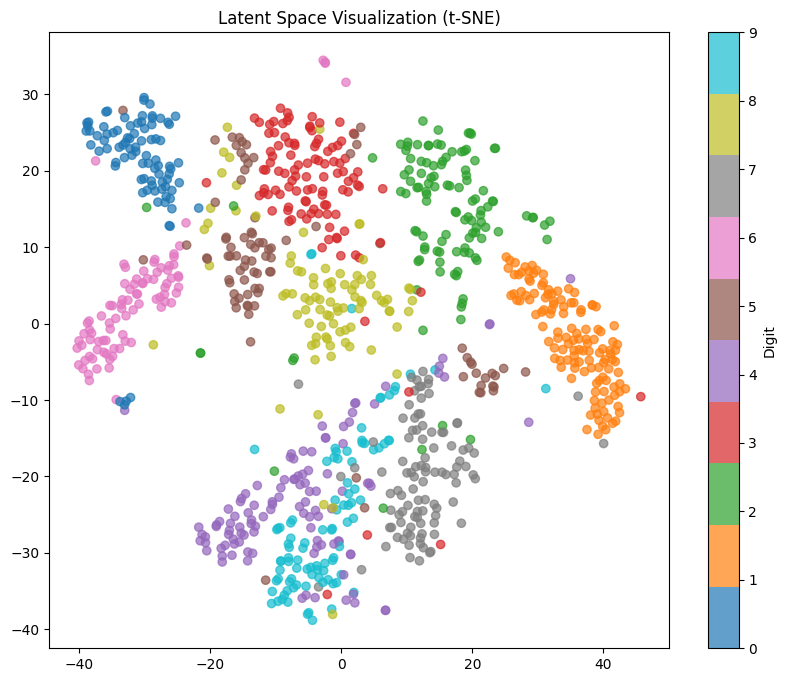

In [28]:
plt.figure(figsize=(10,8))
scatter = plt.scatter(latent_tsne[:,0], latent_tsne[:,1], c=labels_list, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Digit')
plt.title('Latent Space Visualization (t-SNE)')
plt.show()

Task 7. Effect of latent dimension

In [29]:
def train_autoencoder(latent_dim, epochs=15, verbose=True):
    model = Autoencoder(latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            recon, _ = model(images)
            loss = criterion(recon, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * images.size(0)
        epoch_loss /= len(train_loader.dataset)
        train_losses.append(epoch_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)
                recon, _ = model(images)
                val_loss += criterion(recon, images).item() * images.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        if verbose and (epoch+1) % 5 == 0:
            print(f"latent_dim={latent_dim}, Epoch {epoch+1}: val loss = {val_loss:.4f}")
    return val_losses[-1], model

In [30]:
# Compare three different latent dimensions
dims = [16, 64, 256]
results = {}
for dim in dims:
    final_loss, trained_model = train_autoencoder(dim, epochs=15, verbose=True)
    results[dim] = {'loss': final_loss, 'model': trained_model}
    print(f"Latent dim {dim}: final validation loss = {final_loss:.6f}")

latent_dim=16, Epoch 5: val loss = 0.0118
latent_dim=16, Epoch 10: val loss = 0.0099
latent_dim=16, Epoch 15: val loss = 0.0092
Latent dim 16: final validation loss = 0.009186
latent_dim=64, Epoch 5: val loss = 0.0029
latent_dim=64, Epoch 10: val loss = 0.0023
latent_dim=64, Epoch 15: val loss = 0.0021
Latent dim 64: final validation loss = 0.002087
latent_dim=256, Epoch 5: val loss = 0.0016
latent_dim=256, Epoch 10: val loss = 0.0010
latent_dim=256, Epoch 15: val loss = 0.0008
Latent dim 256: final validation loss = 0.000790


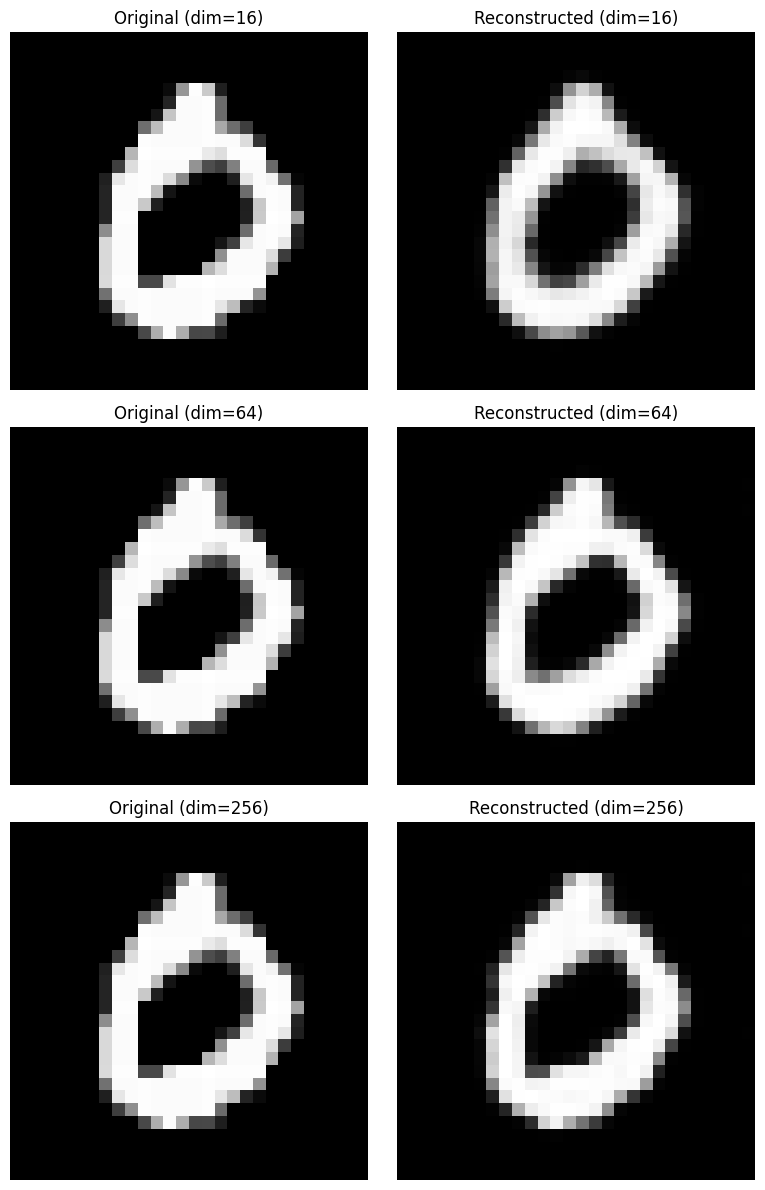

In [31]:
fig, axes = plt.subplots(3, 2, figsize=(8, 12))
sample_imgs = next(iter(test_loader))[0][:4].to(device)

for idx, dim in enumerate(dims):
    model_dim = results[dim]['model']
    model_dim.eval()
    with torch.no_grad():
        recon, _ = model_dim(sample_imgs)
    # Original images (same for all rows)
    for i in range(4):
        axes[idx, 0].imshow(sample_imgs[i].cpu().squeeze(), cmap='gray')
        axes[idx, 0].set_title(f"Original (dim={dim})")
        axes[idx, 0].axis('off')
        axes[idx, 1].imshow(recon[i].cpu().squeeze(), cmap='gray')
        axes[idx, 1].set_title(f"Reconstructed (dim={dim})")
        axes[idx, 1].axis('off')
plt.tight_layout()
plt.show()

Task 8. Denoising autoencoder

In [32]:
class DenoisingAutoencoder(Autoencoder):
    def forward(self, x, noise_factor=0.3):
        noise = torch.randn_like(x) * noise_factor
        noisy_x = x + noise
        noisy_x = torch.clamp(noisy_x, 0., 1.)
        z = self.encoder(noisy_x)
        recon = self.decoder(z)
        return recon, z, noisy_x

In [33]:
# Train denoising autoencoder
denoise_model = DenoisingAutoencoder(latent_dim=64).to(device)
optimizer = torch.optim.Adam(denoise_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [34]:
denoise_train_losses = []
for epoch in range(15):
    denoise_model.train()
    epoch_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        recon, _, _ = denoise_model(images, noise_factor=0.3)
        loss = criterion(recon, images)  # reconstruct clean images
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * images.size(0)
    epoch_loss /= len(train_loader.dataset)
    denoise_train_losses.append(epoch_loss)
    if (epoch+1) % 5 == 0:
        print(f"Denoising Epoch {epoch+1}: loss = {epoch_loss:.4f}")

Denoising Epoch 5: loss = 0.0066
Denoising Epoch 10: loss = 0.0057
Denoising Epoch 15: loss = 0.0053


In [35]:
denoise_model.eval()
with torch.no_grad():
    clean_imgs, _ = next(iter(test_loader))
    clean_imgs = clean_imgs.to(device)
    recon_denoise, _, noisy_imgs = denoise_model(clean_imgs[:8], noise_factor=0.3)

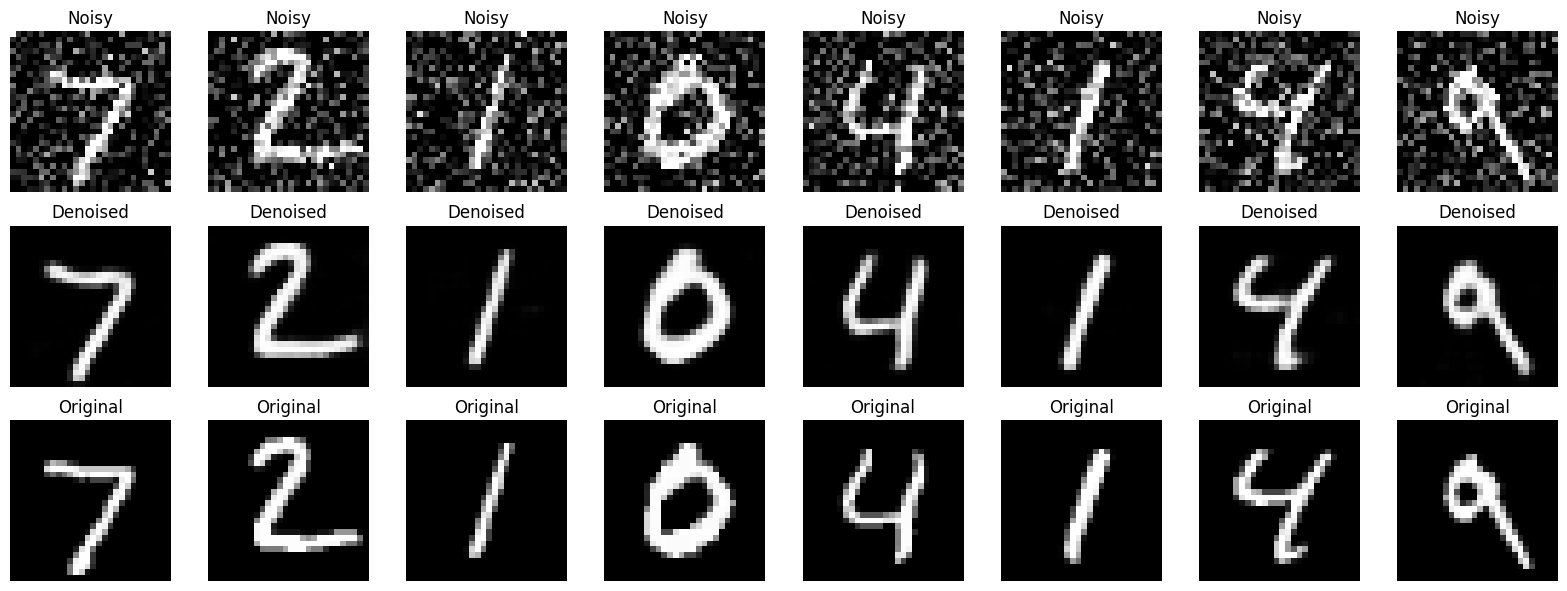

In [36]:
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0, i].imshow(noisy_imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Noisy")
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_denoise[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Denoised")
    axes[1, i].axis('off')
    axes[2, i].imshow(clean_imgs[i].cpu().squeeze(), cmap='gray')
    axes[2, i].set_title("Original")
    axes[2, i].axis('off')
plt.tight_layout()
plt.show()

In [37]:
print(f"Standard AE final val loss: {val_losses[-1]:.6f}")
print(f"Denoising AE final train loss (on noisy input): {denoise_train_losses[-1]:.6f}")

Standard AE final val loss: 0.001945
Denoising AE final train loss (on noisy input): 0.005336


Task 9. Anomaly detection using autoencoder

In [38]:
class SingleClassDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, target_class=0):
        self.images = []
        for img, label in dataset:
            if label == target_class:
                self.images.append(img)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], 0

In [39]:
train_single = SingleClassDataset(train_dataset, target_class=0)
val_single = SingleClassDataset(val_dataset, target_class=0)
test_mixed = test_dataset  # contains all digits

In [40]:
train_loader_single = DataLoader(train_single, batch_size=128, shuffle=True)
val_loader_single = DataLoader(val_single, batch_size=128, shuffle=False)

In [41]:
anomaly_model = Autoencoder(latent_dim=64).to(device)
optimizer = torch.optim.Adam(anomaly_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(15):
    anomaly_model.train()
    epoch_loss = 0
    for images, _ in train_loader_single:
        images = images.to(device)
        recon, _ = anomaly_model(images)
        loss = criterion(recon, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * images.size(0)
    epoch_loss /= len(train_loader_single.dataset)
    if (epoch+1) % 5 == 0:
        print(f"Anomaly AE Epoch {epoch+1}: loss = {epoch_loss:.4f}")

Anomaly AE Epoch 5: loss = 0.0160
Anomaly AE Epoch 10: loss = 0.0079
Anomaly AE Epoch 15: loss = 0.0057


In [42]:
#reconstruction error on test set (all classes)
anomaly_model.eval()
recon_errors = []
true_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        recon, _ = anomaly_model(images)
        mse_per_img = torch.mean((recon - images) ** 2, dim=(1,2,3)).cpu().numpy()
        recon_errors.extend(mse_per_img)
        true_labels.extend(labels.numpy())

recon_errors = np.array(recon_errors)
true_labels = np.array(true_labels)

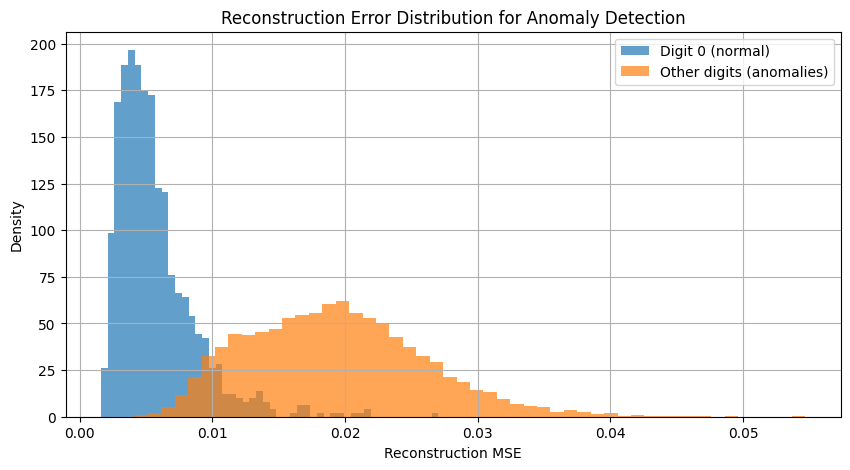

In [43]:
#Separate errors for class 0 (normal) and others (anomalies)
errors_class0 = recon_errors[true_labels == 0]
errors_other = recon_errors[true_labels != 0]

plt.figure(figsize=(10,5))
plt.hist(errors_class0, bins=50, alpha=0.7, label='Digit 0 (normal)', density=True)
plt.hist(errors_other, bins=50, alpha=0.7, label='Other digits (anomalies)', density=True)
plt.xlabel('Reconstruction MSE')
plt.ylabel('Density')
plt.title('Reconstruction Error Distribution for Anomaly Detection')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# Compute threshold (95th percentile of training errors on class 0)
train_errors = []
with torch.no_grad():
    for images, _ in train_loader_single:
        images = images.to(device)
        recon, _ = anomaly_model(images)
        mse = torch.mean((recon - images) ** 2, dim=(1,2,3)).cpu().numpy()
        train_errors.extend(mse)
threshold = np.percentile(train_errors, 95)
print(f"Anomaly threshold (95th percentile): {threshold:.6f}")

Anomaly threshold (95th percentile): 0.010738


In [45]:
#accuracy
predictions = (recon_errors > threshold)
true_anomaly = (true_labels != 0)
accuracy = (predictions == true_anomaly).mean()
print(f"Binary classification accuracy (normal vs anomaly): {accuracy:.3f}")

Binary classification accuracy (normal vs anomaly): 0.910
